C:\Users\Dev Radia\AppData\Local\Temp\ipykernel_21520\575655252.py:44: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(image.ravel(), 256, [0, 256], color="black")
C:\Users\Dev Radia\AppData\Local\Temp\ipykernel_21520\575655252.py:55: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(equalized_img.ravel(), 256, [0, 256], color="blue")
C:\Users\Dev Radia\AppData\Local\Temp\ipykernel_21520\575655252.py:66: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(matched_img.ravel(), 256, [0, 256], color="green")


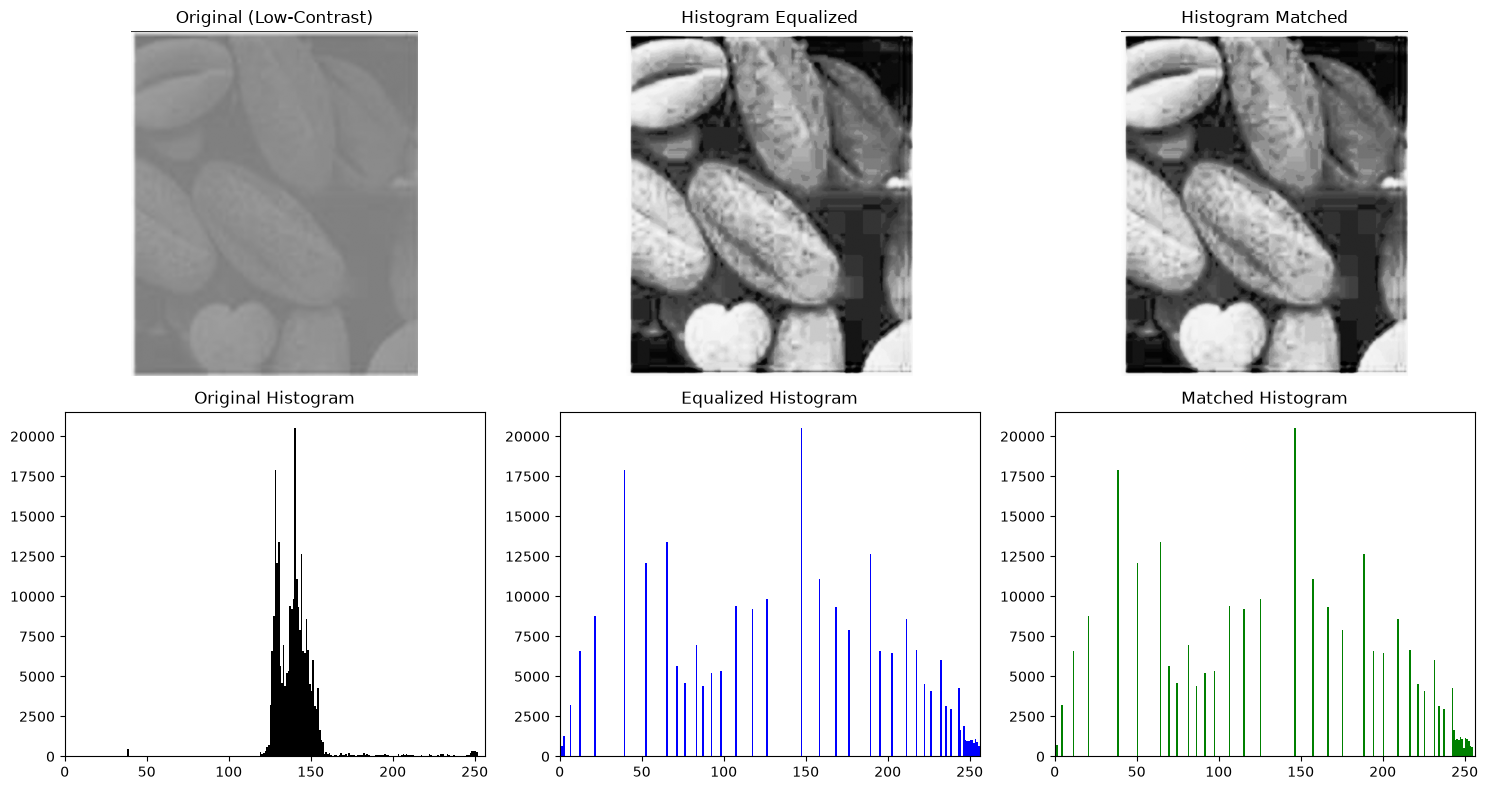

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.exposure import match_histograms

# 1. Load Image 1
image_path = r"C:\Users\Dev Radia\Pictures\Screenshots\Screenshot 2026-09-22 081442.png"
raw_image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

if raw_image is None:
    print("Error: Image not found. Check the path!")
else:
    # Handle alpha channel if present
    if len(raw_image.shape) == 3 and raw_image.shape[2] == 4:
        image = cv2.cvtColor(raw_image, cv2.COLOR_BGRA2GRAY)
    elif len(raw_image.shape) == 3:
        image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2GRAY)
    else:
        image = raw_image

    # 2. Histogram Equalization (Global)
    equalized_img = cv2.equalizeHist(image)

    # 3. Histogram Matching (Specification)
    # Using a synthetic smooth reference with balanced dynamic range
    # (A linear gradient or standard Gaussian-distributed target)
    h, w = image.shape
    x = np.linspace(0, 255, w, dtype=np.uint8)
    synthetic_ref = np.tile(x, (h, 1))

    matched_img = match_histograms(image, synthetic_ref)
    matched_img = np.clip(matched_img, 0, 255).astype(np.uint8)

    # 4. Display Images and Corresponding Histograms
    plt.figure(figsize=(15, 8))

    # Original
    plt.subplot(2, 3, 1)
    plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    plt.title("Original (Low-Contrast)")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.hist(image.ravel(), 256, [0, 256], color="black")
    plt.title("Original Histogram")
    plt.xlim([0, 256])

    # Equalized
    plt.subplot(2, 3, 2)
    plt.imshow(equalized_img, cmap="gray", vmin=0, vmax=255)
    plt.title("Histogram Equalized")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.hist(equalized_img.ravel(), 256, [0, 256], color="blue")
    plt.title("Equalized Histogram")
    plt.xlim([0, 256])

    # Matched
    plt.subplot(2, 3, 3)
    plt.imshow(matched_img, cmap="gray", vmin=0, vmax=255)
    plt.title("Histogram Matched")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.hist(matched_img.ravel(), 256, [0, 256], color="green")
    plt.title("Matched Histogram")
    plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()